# Key Findings and Conclusions

## Dataset Overview
- The dataset contains Tesla EV delivery data from 2015 to 2025.
- Total records available in the dataset: 2640.
- The dataset includes production, pricing, battery, range, CO2 savings, charging infrastructure, and regional information.
- No missing values or duplicate records were found after data cleaning.

---

# Data Cleaning and Preprocessing
- Categorical columns were converted into category data types for better memory efficiency.
- Numerical columns were converted into numeric format.
- Outliers were detected using the IQR (Interquartile Range) method.
- Outliers were handled using clipping to reduce the impact of extreme values without removing records.

---

# Exploratory Data Analysis (EDA)
- Estimated Deliveries showed a strong positive relationship with Production Units.
- CO2 Saved Tons also showed a strong correlation with Estimated Deliveries.
- Other features such as Charging Stations, Battery Capacity, and Range had weaker relationships with the target variable.
- The dataset distribution was relatively balanced across Regions and Tesla Models.

---

# Correlation Analysis
- Production Units had the highest correlation with Estimated Deliveries.
- CO2 Saved Tons was the second most influential feature.
- Battery Capacity and Charging Stations had comparatively lower influence on prediction.

---

# Feature Importance Analysis
- Random Forest Feature Importance revealed that:
  - Production Units was the most important feature.
  - CO2 Saved Tons contributed significantly to predictions.
  - Range and Avg Price also contributed moderately.
  - Region and Source Type had minimal impact on prediction.

---

# Model Comparison Results

| Model | Performance |
|---|---|
| Decision Tree | Good baseline performance |
| Random Forest | Improved prediction accuracy |
| AdaBoost | Better than Decision Tree but weaker than boosting models |
| XGBoost | Very high prediction performance |
| LightGBM | Best overall model |

- Ensemble boosting models performed better than single tree models.
- LightGBM achieved the highest prediction accuracy among all tested models.

---

# Best Model Selection
- LightGBM was selected as the final model because it produced:
  - Lowest RMSE
  - Lowest MAE
  - Highest R² Score

---

# Hyperparameter Tuning
- RandomizedSearchCV was used for tuning the LightGBM model.
- Hyperparameter tuning improved model performance further.
- The tuned model achieved better generalization and reduced prediction error.

---

# Final Model Performance

## Final Evaluation Metrics
- R² Score ≈ 0.994
- RMSE ≈ 280
- MAE ≈ 209

## Interpretation
- The model explains approximately 99.4% of the variance in Estimated Deliveries.
- Average prediction error is approximately ±209 deliveries.
- The prediction results are highly accurate for the given dataset.

---

# Residual Analysis
- Residual distribution was centered around zero, indicating low prediction bias.
- Most prediction errors were relatively small.
- Some large errors were observed in extreme delivery values.

---

# Overall Conclusion
- LightGBM proved to be the most effective model for Tesla delivery prediction.
- Ensemble learning methods significantly outperformed traditional tree models.
- Production Units and CO2 Saved Tons were the strongest predictors in the dataset.
- The final tuned LightGBM model achieved excellent predictive performance and strong generalization capability.

In [1]:
!unzip /content/archive.zip

Archive:  /content/archive.zip
  inflating: tesla_deliveries_dataset_2015_2025.csv  


In [2]:
# STEP 1 : DATA LOADING AND CLEANING

import pandas as pd
import numpy as np

df = pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")

print("Dataset Shape :", df.shape)
print("\nColumns :")
print(df.columns)

print("\nMissing Values :")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

df.drop_duplicates(inplace=True)
cat_cols = ["Region","Model","Source_Type"]

for col in cat_cols:
    df[col] = df[col].astype("category")

num_cols = [
    "Year","Month","Estimated_Deliveries",
    "Production_Units","Avg_Price_USD",
    "Battery_Capacity_kWh","Range_km",
    "CO2_Saved_tons","Charging_Stations"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nData Types :")
print(df.dtypes)

print("\nDataset Preview :")
print(df.head())

Dataset Shape : (2640, 12)

Columns :
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Missing Values :
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows : 0

Data Types :
Year                       int64
Month                      int64
Region                  category
Model                   category
Estimated_Deliveries       int64
Production_Units           int64
Avg_Price_USD            float64
Battery_Capacity_kWh       int64
Range_km                   int64
CO2_Saved_tons           float64
Source_Type             

Boxplots Before Outlier Handling


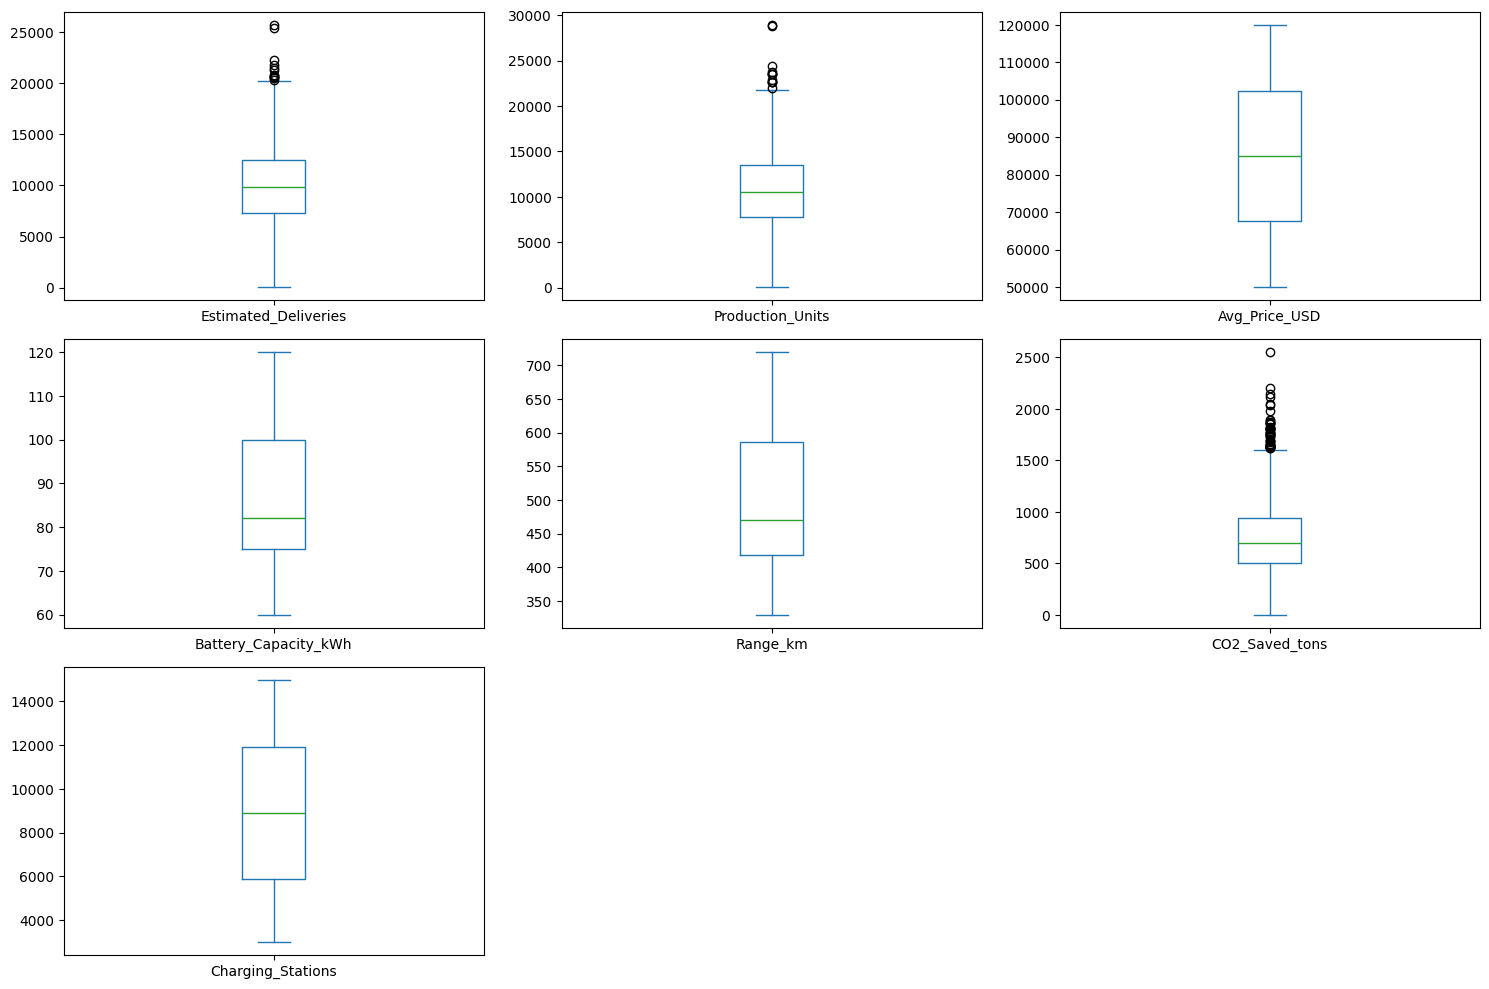


Outlier Summary :
                Feature  Outlier_Count
0  Estimated_Deliveries             12
1      Production_Units             12
2         Avg_Price_USD              0
3  Battery_Capacity_kWh              0
4              Range_km              0
5        CO2_Saved_tons             45
6     Charging_Stations              0

Boxplots After Outlier Handling


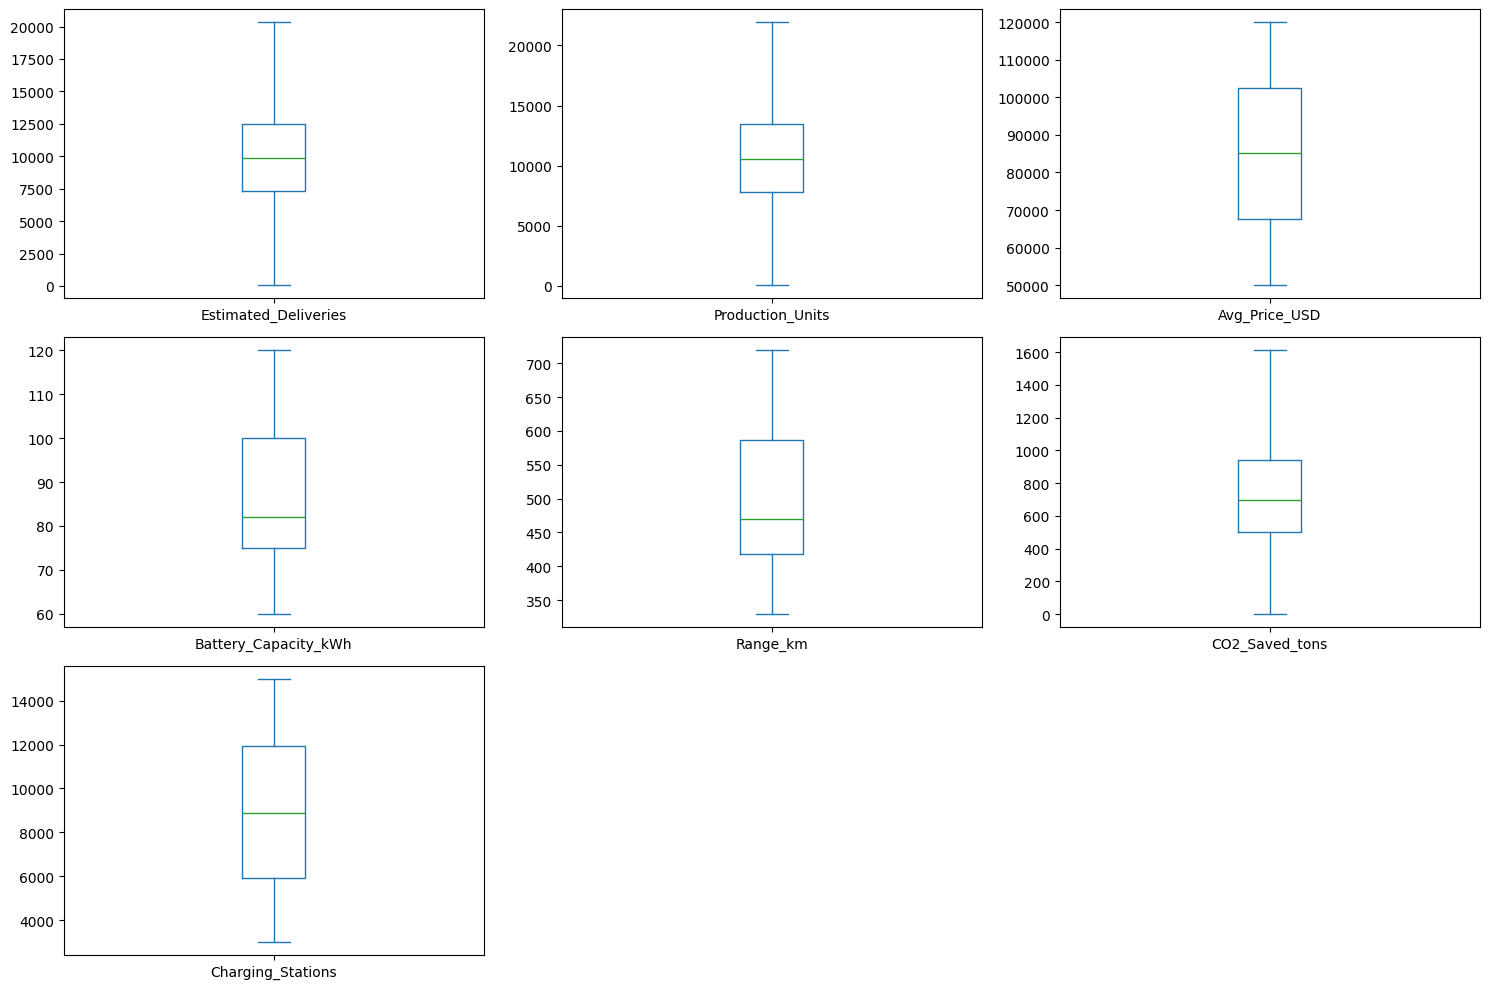

In [3]:
# STEP 2 : OUTLIER DETECTION AND HANDLING

import matplotlib.pyplot as plt

num_cols = [
    "Estimated_Deliveries",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations"
]

print("Boxplots Before Outlier Handling")

df[num_cols].plot(
    kind="box",
    subplots=True,
    layout=(3,3),
    figsize=(15,10)
)

plt.tight_layout()
plt.show()
outlier_data = []

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ].shape[0]

    outlier_data.append([col, outliers])

    df[col] = np.clip(df[col], lower, upper)

outlier_df = pd.DataFrame(
    outlier_data,
    columns=["Feature","Outlier_Count"]
)

print("\nOutlier Summary :")
print(outlier_df)

print("\nBoxplots After Outlier Handling")

df[num_cols].plot(
    kind="box",
    subplots=True,
    layout=(3,3),
    figsize=(15,10)
)

plt.tight_layout()
plt.show()

Dataset Shape : (2640, 12)

Statistical Summary :
       Estimated_Deliveries  Production_Units  Avg_Price_USD  \
count           2640.000000       2640.000000    2640.000000   
mean            9915.586553      10645.946402   84907.340330   
std             3915.341443       4229.104086   20123.258036   
min               48.000000         50.000000   50003.700000   
25%             7292.000000       7828.250000   67726.365000   
50%             9857.000000      10546.500000   85058.510000   
75%            12510.250000      13469.000000  102373.042500   
max            20337.625000      21930.125000  119965.360000   

       Battery_Capacity_kWh     Range_km  CO2_Saved_tons  Charging_Stations  
count           2640.000000  2640.000000     2640.000000        2640.000000  
mean              87.059470   500.257576      740.749255        8932.133712  
std               20.836265   120.868549      343.172810        3469.565883  
min               60.000000   330.000000        3.070000     

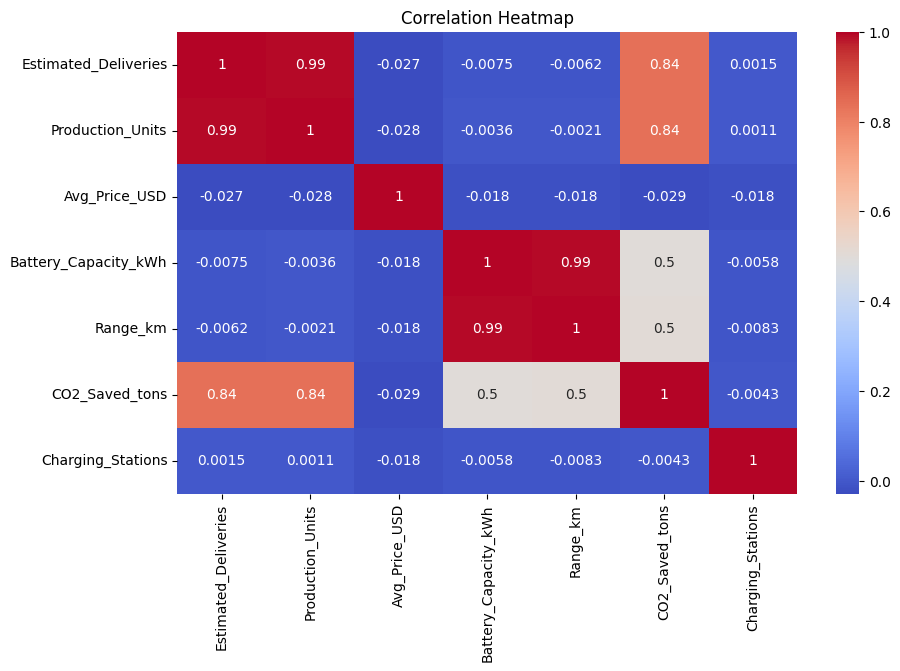

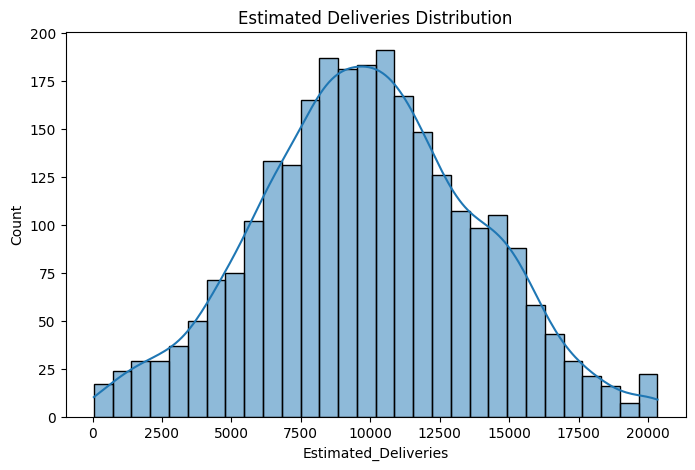

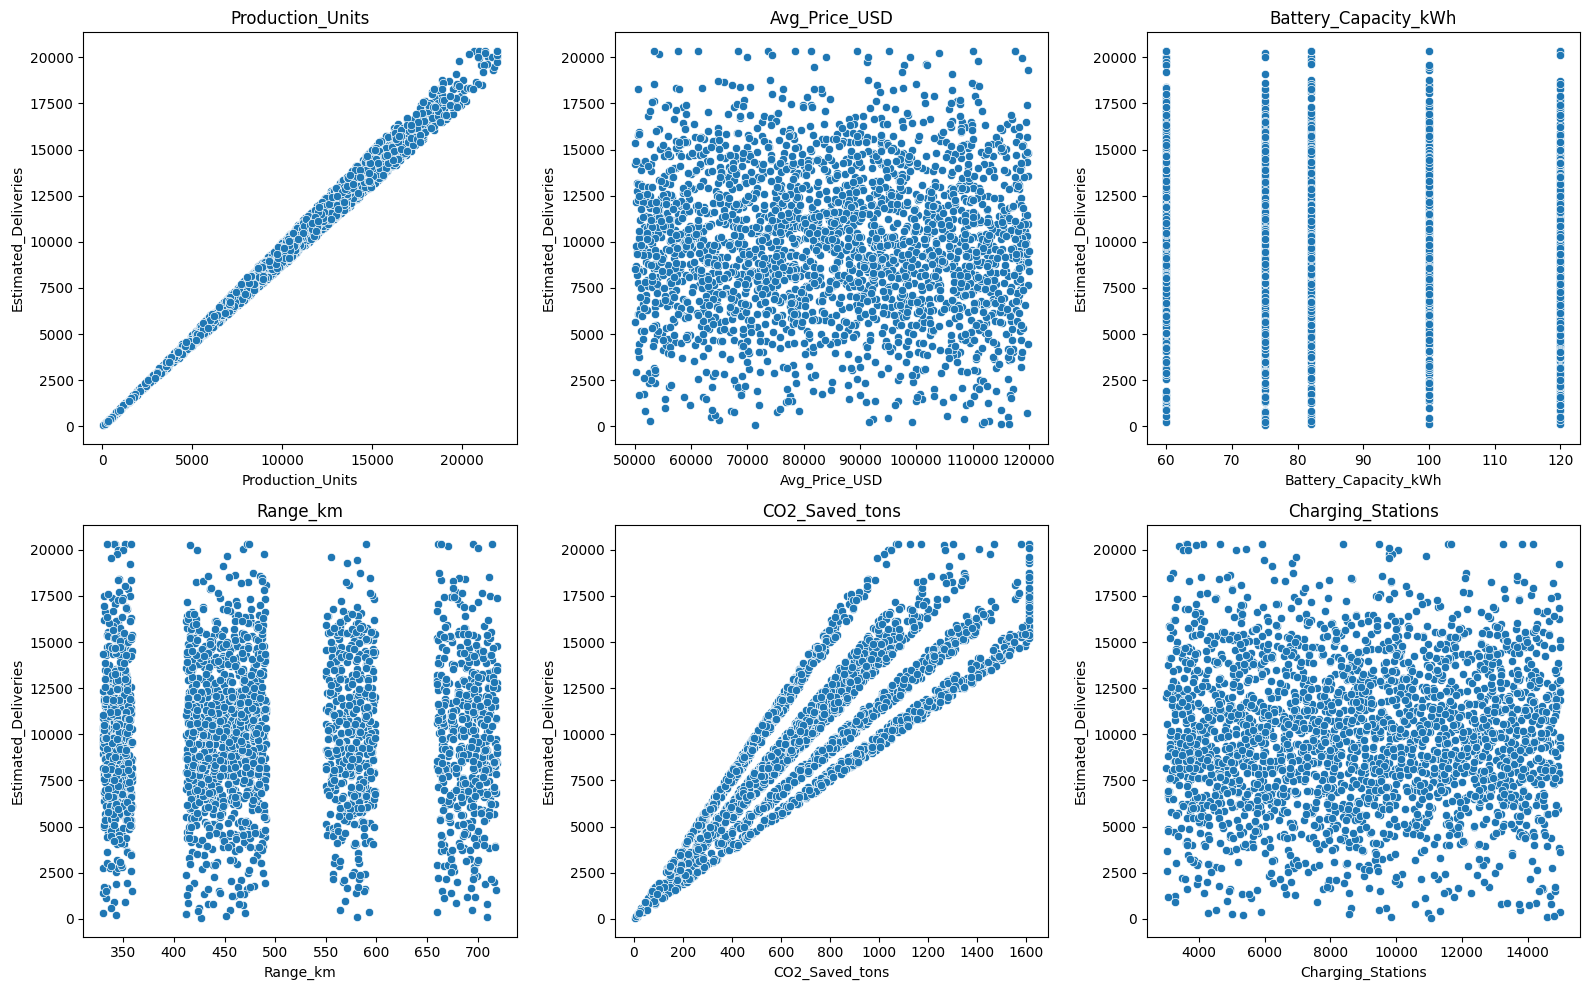

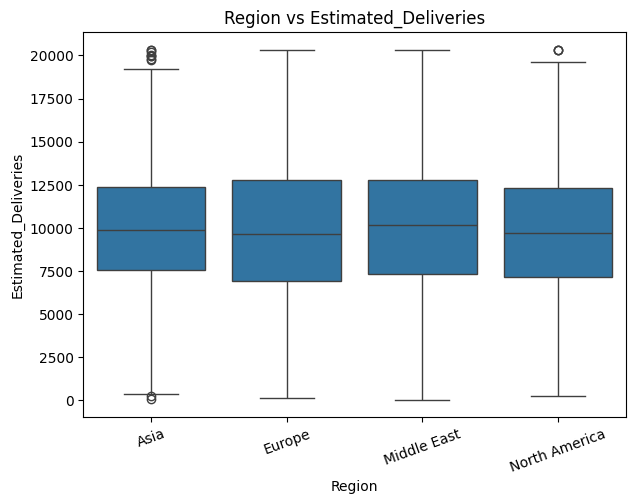

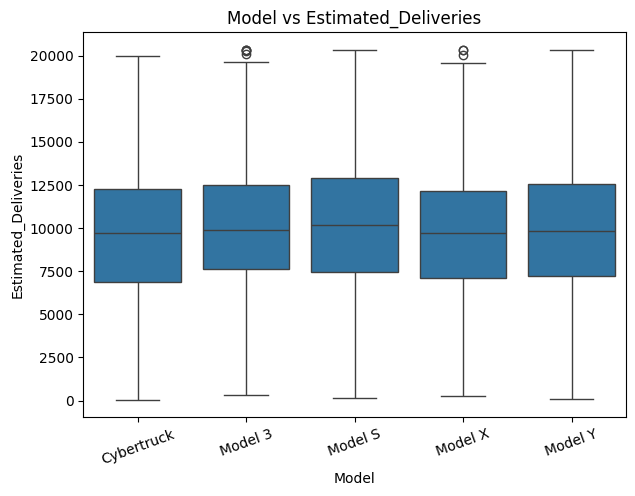

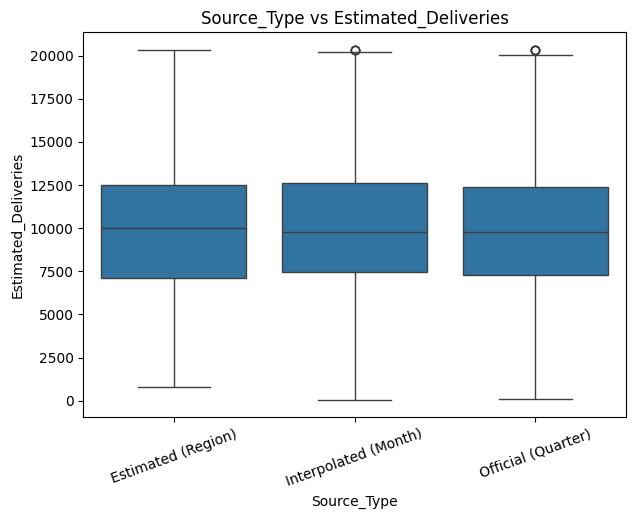


Feature Importance :
                 Feature  Importance
2       Production_Units    0.990689
6         CO2_Saved_tons    0.002490
5               Range_km    0.001577
3          Avg_Price_USD    0.001293
7      Charging_Stations    0.001149
0                   Year    0.000748
1                  Month    0.000734
9                  Model    0.000448
8                 Region    0.000398
10           Source_Type    0.000300
4   Battery_Capacity_kWh    0.000174


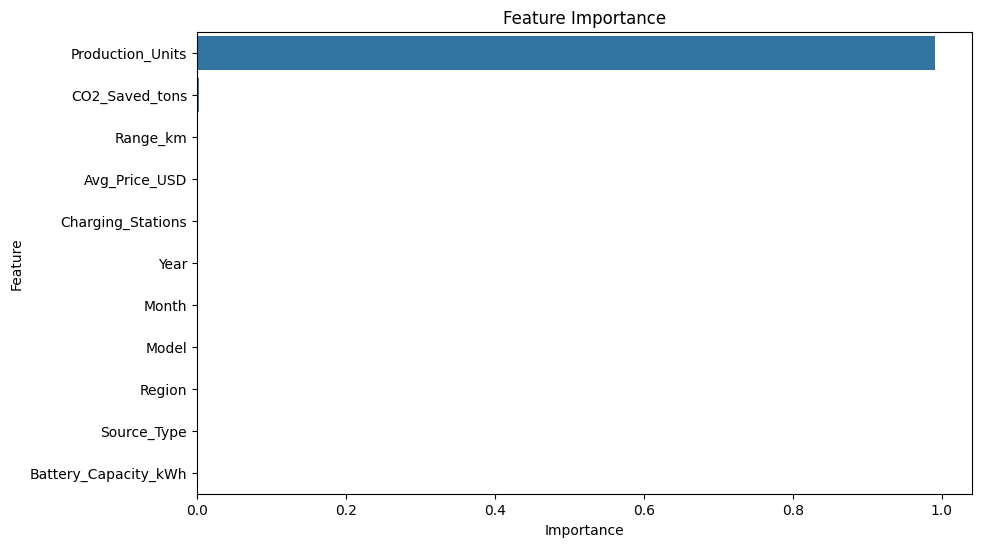

In [4]:
# STEP 3 : EDA + CORRELATION + FEATURE IMPORTANCE

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

num_cols = [
    "Estimated_Deliveries",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations"
]

cat_cols = [
    "Region",
    "Model",
    "Source_Type"
]

print("Dataset Shape :", df.shape)
print("\nStatistical Summary :")
print(df[num_cols].describe())
print("\nCategorical Summary :")

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())

corr_matrix = df[num_cols].corr()

print("\nCorrelation With Target :")
print(corr_matrix["Estimated_Deliveries"].sort_values(ascending=False))

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(8,5))

sns.histplot(
    df["Estimated_Deliveries"],
    bins=30,
    kde=True
)

plt.title("Estimated Deliveries Distribution")
plt.show()

features = [
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations"
]

fig, axes = plt.subplots(2,3,figsize=(16,10))
axes = axes.flatten()

for i,col in enumerate(features):

    sns.scatterplot(
        x=df[col],
        y=df["Estimated_Deliveries"],
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

for col in cat_cols:

    plt.figure(figsize=(7,5))

    sns.boxplot(
        x=df[col],
        y=df["Estimated_Deliveries"]
    )

    plt.title(f"{col} vs Estimated_Deliveries")
    plt.xticks(rotation=20)
    plt.show()

X = df.drop(columns=["Estimated_Deliveries"])
y = df["Estimated_Deliveries"]

cat_features = X.select_dtypes(
    include=["object","category"]
).columns.tolist()

num_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

preprocessor = ColumnTransformer([
    (
        "num",
        SimpleImputer(strategy="median"),
        num_features
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                )
            )
        ]),
        cat_features
    )
])

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ("prep",preprocessor),
    ("model",rf)
])

pipeline.fit(X,y)

importance_df = pd.DataFrame({
    "Feature":num_features + cat_features,
    "Importance":pipeline.named_steps["model"].feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance :")
print(importance_df)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [5]:
# STEP 4 : MODEL TRAINING AND COMPARISON

!pip -q install xgboost lightgbm

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

X = df.drop(columns=["Estimated_Deliveries"])
y = df["Estimated_Deliveries"]

cat_cols = X.select_dtypes(
    include=["object","category"]
).columns.tolist()

num_cols = X.select_dtypes(
    include=["number"]
).columns.tolist()

preprocessor = ColumnTransformer([
    (
        "num",
        SimpleImputer(strategy="median"),
        num_cols
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]),
        cat_cols
    )
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

models = {

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "AdaBoost": AdaBoostRegressor(
        n_estimators=300,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append([name, rmse, mae, r2])

    print(f"\n{name}")
    print("RMSE :", round(rmse,4))
    print("MAE :", round(mae,4))
    print("R2 Score :", round(r2,6))

results_df = pd.DataFrame(
    results,
    columns=["Model","RMSE","MAE","R2"]
)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
)

print("\nFinal Model Comparison")
print(results_df)


Decision Tree
RMSE : 522.2831
MAE : 391.0303
R2 Score : 0.9817

Random Forest
RMSE : 407.7489
MAE : 322.015
R2 Score : 0.988846

AdaBoost
RMSE : 429.913
MAE : 344.8569
R2 Score : 0.987601

XGBoost
RMSE : 315.1886
MAE : 230.4403
R2 Score : 0.993335

LightGBM
RMSE : 278.6003
MAE : 203.7544
R2 Score : 0.994793

Final Model Comparison
           Model        RMSE         MAE        R2
4       LightGBM  278.600343  203.754354  0.994793
3        XGBoost  315.188610  230.440279  0.993335
1  Random Forest  407.748923  322.015001  0.988846
2       AdaBoost  429.913036  344.856947  0.987601
0  Decision Tree  522.283082  391.030303  0.981700


RMSE : 301.6189
MAE : 224.714
R2 Score : 0.993897

Prediction Sample :
    Actual     Predicted
0   6991.0   7394.259809
1   9326.0   9430.851492
2   9061.0   8998.064710
3   8951.0   9242.918899
4   8707.0   8865.536389
5  11351.0  11513.781531
6  14193.0  13967.414029
7  15156.0  14600.197177
8   9915.0  10119.407149
9   7642.0   7807.746729


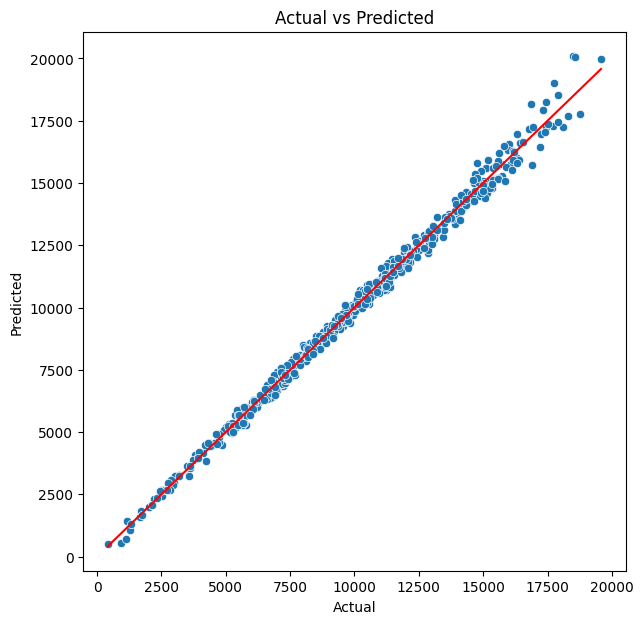

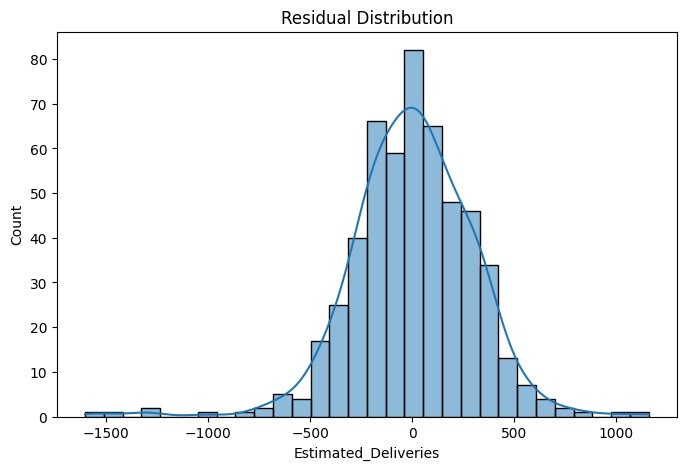

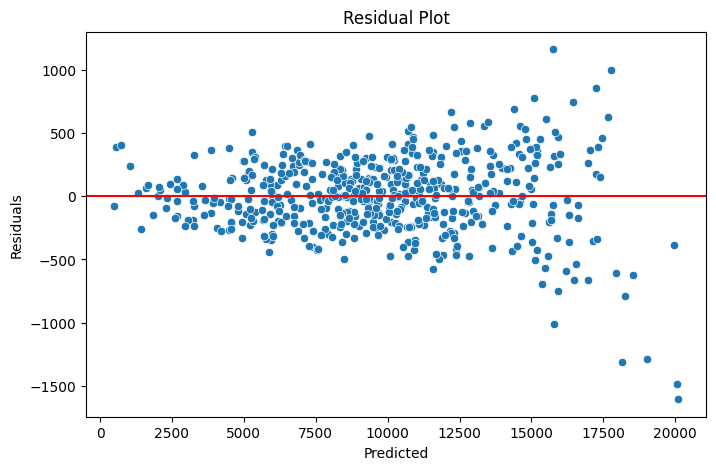


Top Feature Importance :
                             Feature  Importance
2                   Production_Units        3593
6                     CO2_Saved_tons        3119
5                           Range_km        1969
3                      Avg_Price_USD         800
7                  Charging_Stations         613
1                              Month         419
4               Battery_Capacity_kWh         415
0                               Year         333
18  Source_Type_Interpolated (Month)          82
17    Source_Type_Estimated (Region)          63
14                     Model_Model S          53
10                Region_Middle East          44
13                     Model_Model 3          44
8                        Region_Asia          40
9                      Region_Europe          38


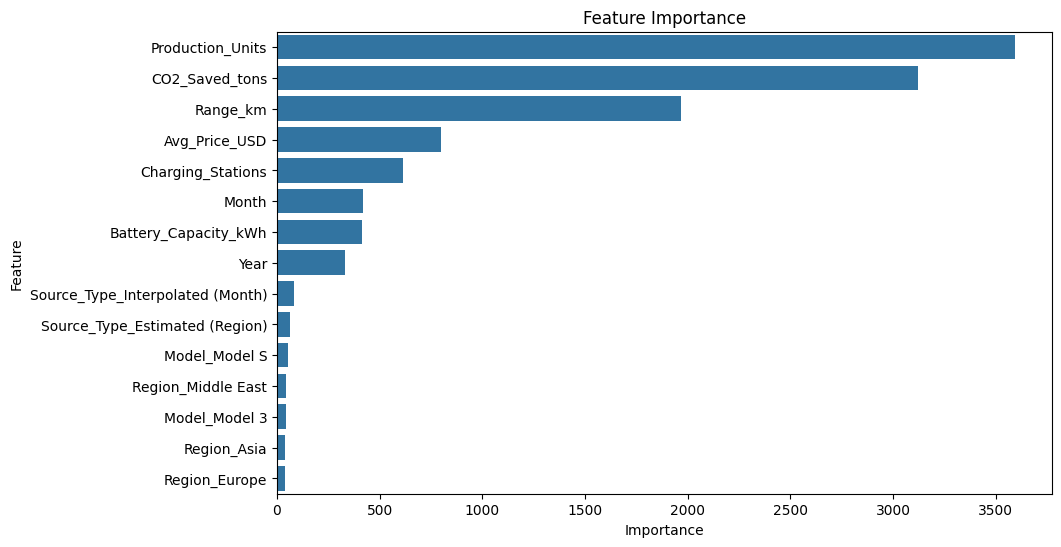

In [6]:
# STEP 5 : LIGHTGBM MODEL ANALYSIS

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from lightgbm import LGBMRegressor

X = df.drop(columns=["Estimated_Deliveries"])
y = df["Estimated_Deliveries"]

cat_cols = X.select_dtypes(
    include=["object","category"]
).columns.tolist()

num_cols = X.select_dtypes(
    include=["number"]
).columns.tolist()

preprocessor = ColumnTransformer([
    (
        "num",
        SimpleImputer(strategy="median"),
        num_cols
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]),
        cat_cols
    )
])

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

pipeline = Pipeline([
    ("prep",preprocessor),
    ("model",model)
])

pipeline.fit(X_train,y_train)

preds = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test,preds))
mae = mean_absolute_error(y_test,preds)
r2 = r2_score(y_test,preds)

print("RMSE :", round(rmse,4))
print("MAE :", round(mae,4))
print("R2 Score :", round(r2,6))

results_df = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":preds
})

print("\nPrediction Sample :")
print(results_df.head(10))

plt.figure(figsize=(7,7))

sns.scatterplot(
    x=y_test,
    y=preds
)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color="red"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

residuals = y_test - preds

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=preds,
    y=residuals
)

plt.axhline(y=0,color="red")

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

feature_names = (
    num_cols +
    list(
        pipeline.named_steps["prep"]
        .named_transformers_["cat"]
        .named_steps["encoder"]
        .get_feature_names_out(cat_cols)
    )
)

importance_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":pipeline.named_steps["model"].feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Feature Importance :")
print(importance_df.head(15))

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [7]:
# STEP 6 : LIGHTGBM HYPERPARAMETER TUNING

from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

param_grid = {
    "model__n_estimators":[200,300,500,700,1000],
    "model__learning_rate":[ 0.01,0.03,0.05,0.07,0.1],
    "model__max_depth":[ 3,5,6,8,10 ],
    "model__num_leaves":[ 15,31,50,70,100],
    "model__subsample":[ 0.6,0.7,0.8,0.9,1.0 ],
    "model__colsample_bytree":[ 0.6,0.7,0.8,0.9,1.0 ],
    "model__min_child_samples":[ 5,10,20,30,50 ]
}

pipeline = Pipeline([
    ("prep",preprocessor),
    ("model",model)
])

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring="r2",
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train,y_train)

print("Best Parameters :")
print(random_search.best_params_)

print("\nBest Cross Validation Score :")
print(random_search.best_score_)

best_model = random_search.best_estimator_

preds = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test,preds))
mae = mean_absolute_error(y_test,preds)
r2 = r2_score(y_test,preds)

print("\nFinal Tuned Metrics")

print("RMSE :", round(rmse,4))
print("MAE :", round(mae,4))
print("R2 Score :", round(r2,6))

Best Parameters :
{'model__subsample': 1.0, 'model__num_leaves': 70, 'model__n_estimators': 500, 'model__min_child_samples': 20, 'model__max_depth': 10, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}

Best Cross Validation Score :
0.9933763675854297

Final Tuned Metrics
RMSE : 291.2157
MAE : 219.3309
R2 Score : 0.994311


Prediction Error Summary :
          Residual  Absolute_Error
count   528.000000      528.000000
mean      5.715142      219.330922
std     291.435717      191.755485
min   -1401.457374        1.171173
25%    -167.950402       80.815707
50%      -7.973404      175.355830
75%     178.616977      304.629498
max    1275.912327     1401.457374


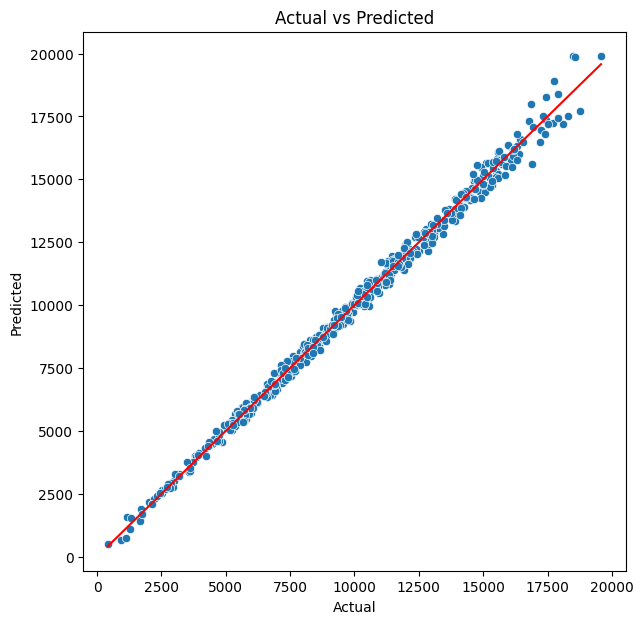

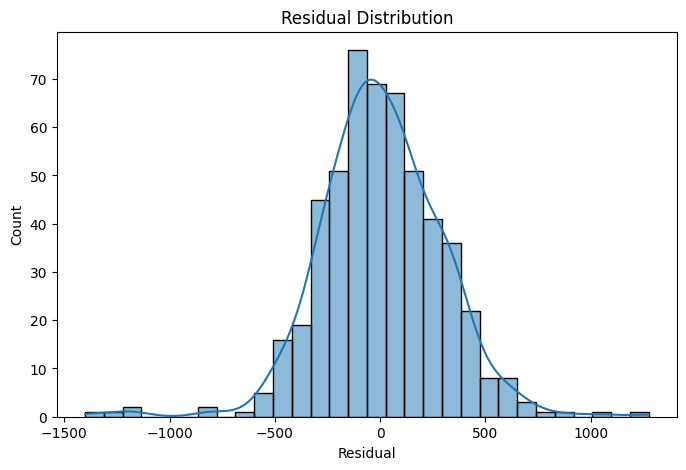

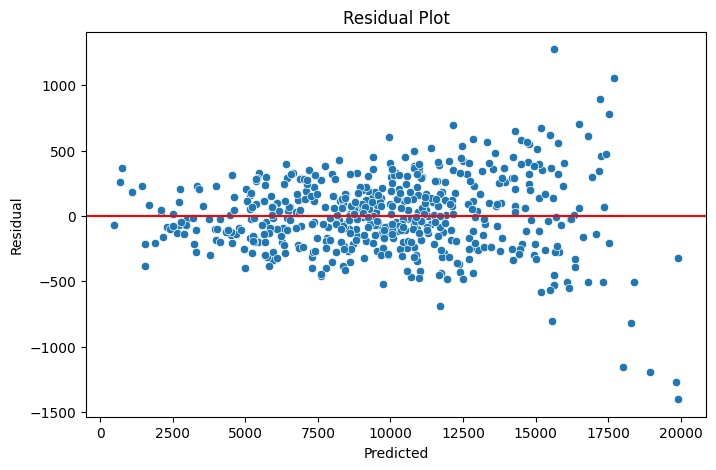


Top 10 Largest Errors :
      Actual     Predicted     Residual  Absolute_Error
425  18486.0  19887.457374 -1401.457374     1401.457374
327  16904.0  15628.087673  1275.912327     1275.912327
523  18572.0  19844.960219 -1272.960219     1272.960219
65   17733.0  18924.453465 -1191.453465     1191.453465
216  16842.0  17994.755203 -1152.755203     1152.755203
171  18761.0  17703.875439  1057.124561     1057.124561
18   18097.0  17202.257080   894.742920      894.742920
155  17456.0  18272.979106  -816.979106      816.979106
376  14778.0  15577.727352  -799.727352      799.727352
179  18301.0  17522.316046   778.683954      778.683954

Top Feature Importance :
                             Feature  Importance
2                   Production_Units        5975
6                     CO2_Saved_tons        5887
5                           Range_km        4659
3                      Avg_Price_USD        2481
7                  Charging_Stations        2136
1                              Month   

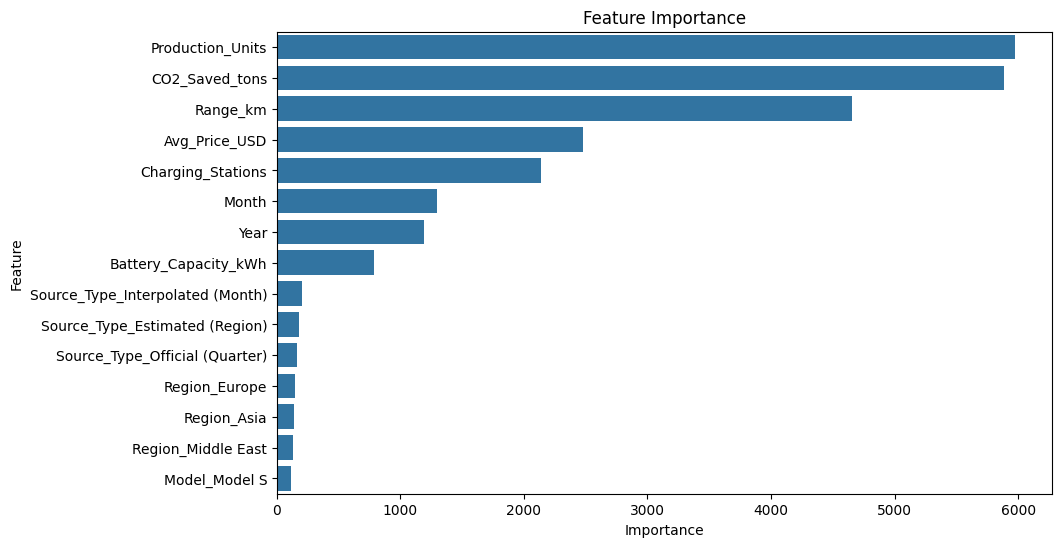

In [8]:
# STEP 7 : FINAL MODEL VALIDATION

import matplotlib.pyplot as plt
import seaborn as sns

final_model = random_search.best_estimator_

preds = final_model.predict(X_test)

results_df = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":preds
})

results_df["Residual"] = (
    results_df["Actual"] -
    results_df["Predicted"]
)

results_df["Absolute_Error"] = (
    np.abs(results_df["Residual"])
)

print("Prediction Error Summary :")
print(
    results_df[
        ["Residual","Absolute_Error"]
    ].describe()
)

plt.figure(figsize=(7,7))

sns.scatterplot(
    x=results_df["Actual"],
    y=results_df["Predicted"]
)

plt.plot(
    [results_df["Actual"].min(), results_df["Actual"].max()],
    [results_df["Actual"].min(), results_df["Actual"].max()],
    color="red"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

plt.figure(figsize=(8,5))

sns.histplot(
    results_df["Residual"],
    bins=30,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=results_df["Predicted"],
    y=results_df["Residual"]
)

plt.axhline(y=0,color="red")

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

top_errors = (
    results_df
    .sort_values(
        by="Absolute_Error",
        ascending=False
    )
    .head(10)
)

print("\nTop 10 Largest Errors :")
print(top_errors)

feature_names = (
    num_cols +
    list(
        final_model.named_steps["prep"]
        .named_transformers_["cat"]
        .named_steps["encoder"]
        .get_feature_names_out(cat_cols)
    )
)

importance_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":final_model.named_steps["model"].feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Feature Importance :")
print(importance_df.head(15))

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

Final Regression Metrics
R2 Score : 0.994311
MAE : 219.3309
MSE : 84806.5786
RMSE : 291.2157
Median Absolute Error : 175.3558
Explained Variance Score : 0.994313
MAPE : 0.025733

Prediction Samples :
     Actual     Predicted       Error  Absolute_Error
0    6991.0   7307.617774 -316.617774      316.617774
1    9326.0   9333.460576   -7.460576        7.460576
2    9061.0   9069.486232   -8.486232        8.486232
3    8951.0   9145.855945 -194.855945      194.855945
4    8707.0   8859.813872 -152.813872      152.813872
5   11351.0  11408.847577  -57.847577       57.847577
6   14193.0  13932.015772  260.984228      260.984228
7   15156.0  14739.166094  416.833906      416.833906
8    9915.0  10086.570763 -171.570763      171.570763
9    7642.0   7812.124480 -170.124480      170.124480
10   8848.0   8801.906948   46.093052       46.093052
11   9563.0   9692.044814 -129.044814      129.044814
12   9497.0   9564.060928  -67.060928       67.060928
13   3031.0   3247.575119 -216.575119      2

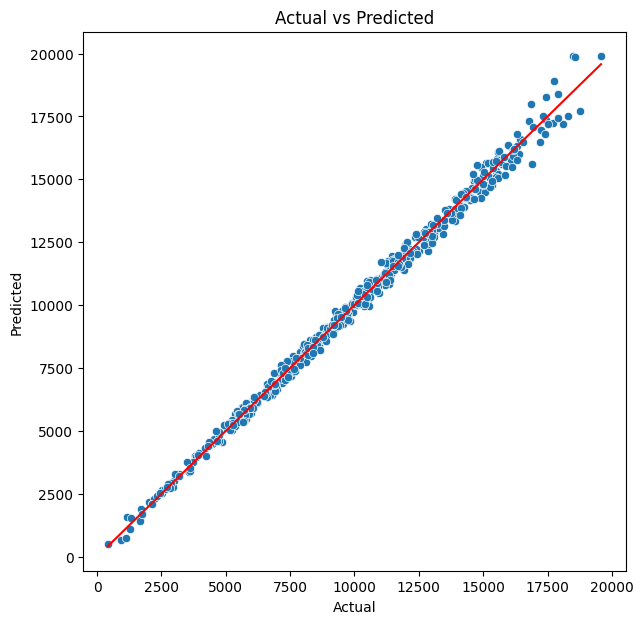

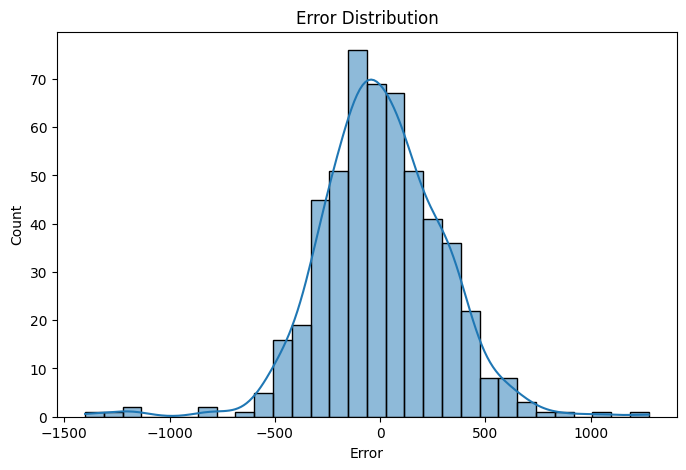


Average Prediction Error : ± 219.33


In [10]:
# STEP 8 : FINAL TRAINING AND EVALUATION

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    explained_variance_score,
    mean_absolute_percentage_error
)

import matplotlib.pyplot as plt
import seaborn as sns

final_model = random_search.best_estimator_

final_model.fit(X_train,y_train)

preds = final_model.predict(X_test)

r2 = r2_score(y_test,preds)
mae = mean_absolute_error(y_test,preds)
mse = mean_squared_error(y_test,preds)
rmse = np.sqrt(mse)

medae = median_absolute_error(
    y_test,
    preds
)

evs = explained_variance_score(
    y_test,
    preds
)

mape = mean_absolute_percentage_error(
    y_test,
    preds
)

print("Final Regression Metrics")

print("R2 Score :", round(r2,6))
print("MAE :", round(mae,4))
print("MSE :", round(mse,4))
print("RMSE :", round(rmse,4))
print("Median Absolute Error :", round(medae,4))
print("Explained Variance Score :", round(evs,6))
print("MAPE :", round(mape,6))

final_results = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":preds
})

final_results["Error"] = (
    final_results["Actual"] -
    final_results["Predicted"]
)

final_results["Absolute_Error"] = (np.abs(final_results["Error"]))

print("\nPrediction Samples :")
print(final_results.head(20))

best_preds = (
    final_results
    .sort_values(by="Absolute_Error")
    .head(10)
)

print("\nMost Accurate Predictions :")
print(best_preds)

worst_preds = (
    final_results
    .sort_values(
        by="Absolute_Error",
        ascending=False
    )
    .head(10)
)

print("\nWorst Predictions :")
print(worst_preds)

plt.figure(figsize=(7,7))

sns.scatterplot(
    x=y_test,
    y=preds
)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color="red"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

plt.figure(figsize=(8,5))

sns.histplot(
    final_results["Error"],
    bins=30,
    kde=True
)

plt.title("Error Distribution")

plt.show()

print(
    "\nAverage Prediction Error : ±",
    round(mae,2)
)